# Modellering af kundetilfredshed og loyalitet med en strukturel ligningsmodel (PROC CALIS)

## Resumé

Denne notebook tilpasser en strukturel ligningsmodel (SEM) for en detailhandler af forbrugsvarer og forbinder to latente drivere — opfattet servicekvalitet og opfattet værdi — til latent kunde**tilfredshed** og derfra til latent **loyalitet**. Ved hjælp af PROC CALIS med LINEQS-modelleringssproget (Bentler-Weeks) estimerer den målemodellen for hvert konstrukt og de strukturelle stier mellem dem samtidigt og korrigerer de strukturelle estimater for målefejl.

På en survey med 100 respondenter passer modellen godt: chi-i-anden = 50.81 med 49 frihedsgrader (p = 0.40), RMSEA = 0.019, CFI = 0.999, TLI = 0.998. De strukturelle stier genfundet fra data er **tilfredshed på servicekvalitet = 0.51** og **på værdi = 0.26**, og **loyalitet på tilfredshed = 0.80** med en lille direkte **loyalitet på værdi = 0.15**. Læst samlet rejser det meste af værdiens indflydelse på loyalitet *gennem* tilfredshed (indirekte effekt 0.26 × 0.80 = 0.21, mod en direkte effekt på 0.15), og servicekvalitet når loyalitet næsten udelukkende gennem tilfredshed (0.51 × 0.80 = 0.41). Det praktiske budskab: tilfredshed er den dominerende løftestang for loyalitet, og servicekvalitet er den mere effektive måde at hæve tilfredsheden på i første omgang.

## Datakilder

Alle data genereres inline i det første DATA-trin (ingen eksterne filer). En latent "sand" tilfredshedsrejse simuleres for hver survey-respondent, hvorefter hvert konstrukt observeres gennem tre støjfyldte Likert-lignende indikatoritems.

| Datasæt | Rækker | Variabel | Rolle | Beskrivelse |
|---------|------|----------|------|-------------|
| `survey` | 100 | `respid` | ID | Respondentidentifikator |
| | | `q1`–`q3` | Indikatorer | Servicekvalitets-items (latent ServQual) |
| | | `v1`–`v3` | Indikatorer | Opfattet værdi-items (latent Value) |
| | | `s1`–`s3` | Indikatorer | Tilfredshedsitems (latent Satis) |
| | | `l1`–`l3` | Indikatorer | Loyalitetsitems (latent Loyal) |

Indikatorerne er kontinuerte standardiserede scorer (centreret ~0) bygget som `loading * latent + Normal noise`, så måle- og strukturparametrene, som PROC CALIS genfinder, er velidentificerede. ServQual og Value er korrelerede eksogene latente variable; Satis regresseres på begge, og Loyal regresseres på Satis med en mindre direkte sti fra Value, hvilket lader os adskille den indirekte (gennem tilfredshed) kanal fra den direkte.

# Kundetilfredshed → loyalitet: En strukturel ligningsmodel

En detailhandler af forbrugsvarer gennemfører en survey efter køb for at forstå, hvad der driver gentagne køb. Den arbejdende teori er en klassisk tilfredsheds-loyalitetskæde:

- **Servicekvalitet** og **opfattet værdi** er to forskellige ting, kunderne oplever.
- Begge føder den samlede **tilfredshed**.
- Tilfredshed driver til gengæld **loyalitet** (intention om at genkøbe / anbefale).

Ingen af disse fire konstrukter observeres direkte. Hvert er *latent* og måles ved tre survey-items. En strukturel ligningsmodel (SEM) er det rette værktøj: den estimerer **målemodellen** (hvordan items lader på konstrukter) og **strukturmodellen** (hvordan konstrukter påvirker hinanden) samtidigt og korrigerer de strukturelle estimater for målefejl.

Vi bruger **PROC CALIS** med **LINEQS**-modelleringssproget (Bentler-Weeks-notation).

## Trin 1 — Simulér en realistisk survey

Vi genererer 100 respondenter. For hver trækker vi de to korrelerede eksogene drivere (servicekvalitet, værdi), bygger derefter tilfredshed som en funktion af begge og loyalitet som en funktion af tilfredshed plus en lille direkte værdieffekt. Til sidst måles hvert konstrukt ved tre støjfyldte indikatoritems, præcis som et Likert-batteri ville opføre sig. `call streaminit` fastlægger frøet for reproducerbarhed.

In [1]:
data survey;
   CALL streaminit(20260531);
   GØR respid = 1 TIL 100;
      /* Two correlated exogenous latent drivers */
      z = rand("normal");
      servqual = 0.6*z + 0.8*rand("normal");   /* perceived service quality */
      VALUE    = 0.6*z + 0.8*rand("normal");   /* perceived value          */

      /* Structural model: satisfaction driven by both drivers */
      satis = 0.55*servqual + 0.40*VALUE + 0.55*rand("normal");

      /* Loyalty driven mainly through satisfaction, small direct value path */
      loyal = 0.70*satis + 0.20*VALUE + 0.50*rand("normal");

      /* Measurement model: 3 indicators per latent construct */
      q1 = 1.00*servqual + 0.45*rand("normal");
      q2 = 0.90*servqual + 0.45*rand("normal");
      q3 = 0.85*servqual + 0.45*rand("normal");

      v1 = 1.00*VALUE + 0.45*rand("normal");
      v2 = 0.95*VALUE + 0.45*rand("normal");
      v3 = 0.80*VALUE + 0.45*rand("normal");

      s1 = 1.00*satis + 0.40*rand("normal");
      s2 = 0.92*satis + 0.40*rand("normal");
      s3 = 0.88*satis + 0.40*rand("normal");

      l1 = 1.00*loyal + 0.40*rand("normal");
      l2 = 0.93*loyal + 0.40*rand("normal");
      l3 = 0.86*loyal + 0.40*rand("normal");

      UDDATA;
   SLUT;
   BEHOLD respid q1-q3 v1-v3 s1-s3 l1-l3;
KØR;


NOTE: DATA survey


NOTE: Wrote survey (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


## Trin 2 — Inspicér de målte items

Før modelleringen et hurtigt kig på item-fordelingerne og korrelationsstrukturen. Items inden for et konstrukt bør korrelere stærkt; items på tværs af konstrukter svagere. Dette er, hvad en konfirmatorisk faktorstruktur antager.

                                                  The MEANS Procedure

 Variable         N        Mean     Std Dev     Minimum     Maximum
 ------------------------------------------------------------------
 q1             100       -0.23        1.24       -4.00        2.78
 q2             100       -0.13        1.13       -2.91        2.79
 q3             100       -0.16        1.12       -3.20        2.65
 v1             100       -0.03        1.09       -2.73        2.54
 v2             100       -0.05        1.12       -3.08        2.52
 v3             100       -0.00        0.93       -3.16        2.12
 s1             100       -0.11        0.97       -2.61        2.26
 s2             100       -0.23        1.01       -2.30        2.44
 s3             100       -0.08        0.90       -2.39        2.41
 l1             100       -0.03        1.03       -2.06        2.26
 l2             100       -0.06        0.95       -2.20        1.99
 l3             100       -0.11        0.86  


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC CORR data=survey

NOTE: ODS plot written: corr_heatmap.spec.json
NOTE: PROC CORR ODS Graphics generated.


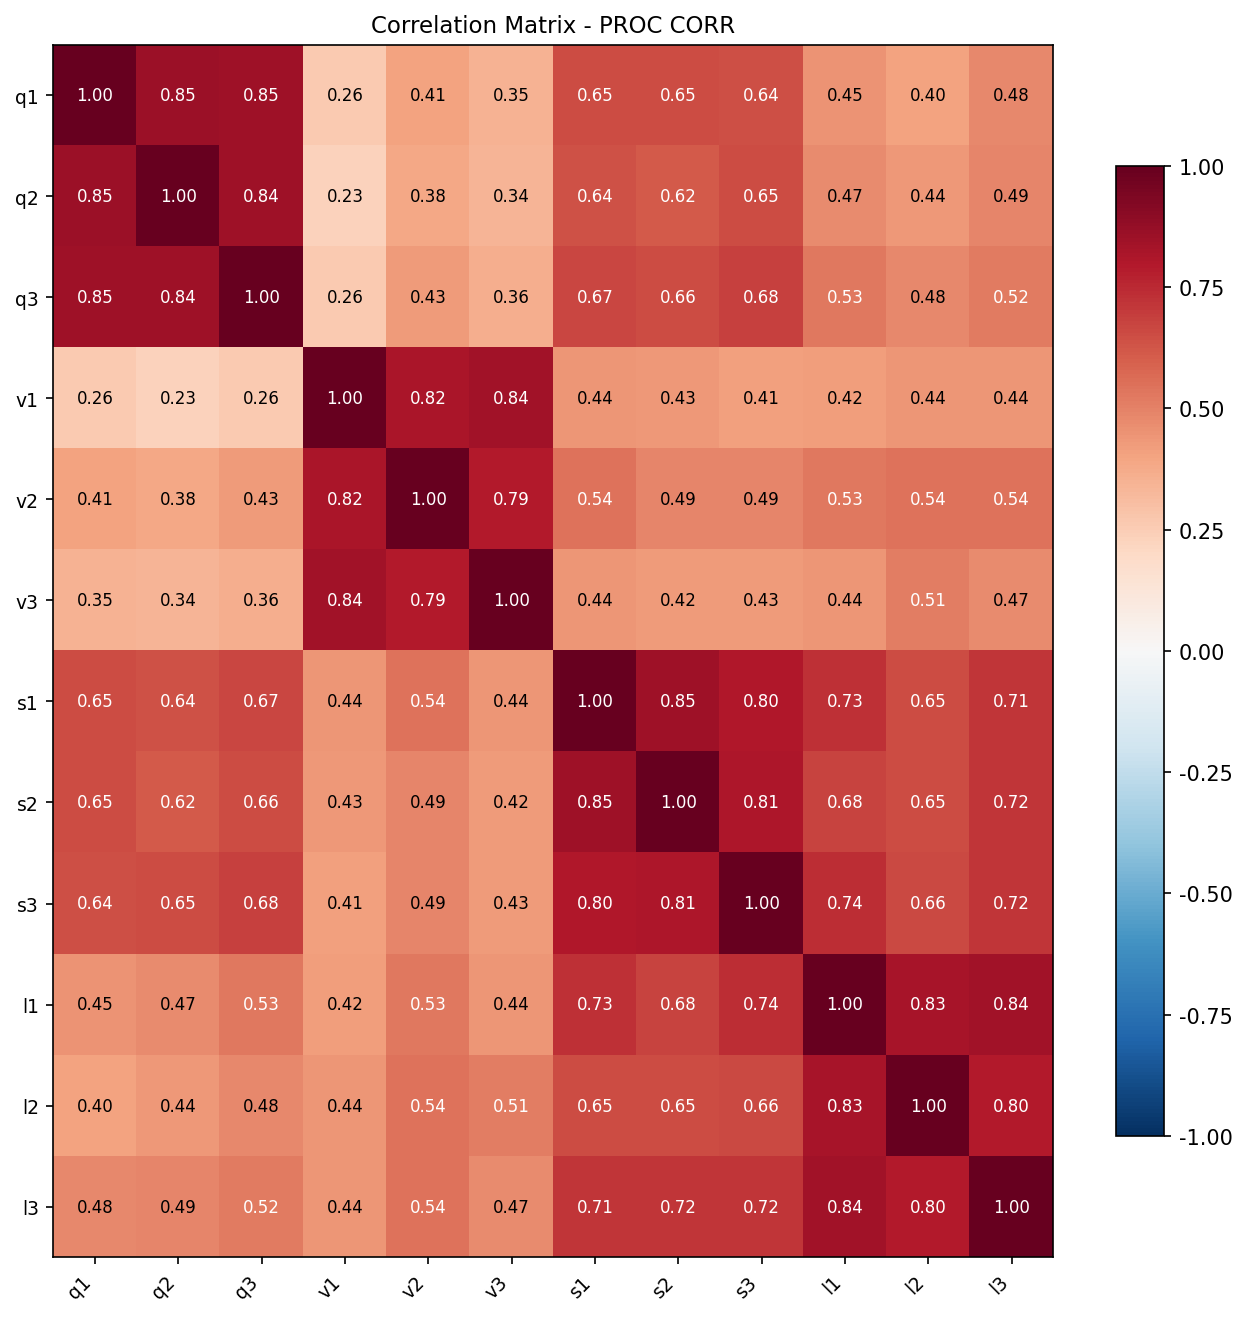

In [2]:
PROCEDURE GENNEMSNIT data=survey n mean std MIN MAX maxdec=2;
   VARIABEL q1-q3 v1-v3 s1-s3 l1-l3;
KØR;

PROCEDURE CORR data=survey nosimple noprob;
   VARIABEL q1 q2 q3 v1 v2 v3 s1 s2 s3 l1 l2 l3;
KØR;

## Trin 3 — Tilpas den fulde SEM

LINEQS-specifikationen har to lag:

**Måleligninger** — hvert observeret item er lig med en loading gange dens latente faktor plus et unikt fejlled (`e1`–`e12`). Vi fastlåser den første loading for hvert konstrukt til `1.0` for at fastsætte den latente skala; de resterende loadings er frie parametre (navngivet `lq2`, `ls3`, ... så de fremgår ved navn i outputtet). Hvert fejlled deklareres i `variance`-sætningen.

**Strukturligninger** — `Satis` regresseres på `ServQual` og `Value`; `Loyal` regresseres på `Satis` og `Value` (en lille direkte sti). Hver endogen latent bærer sit eget forstyrrelsesled (`d1` for tilfredshed, `d2` for loyalitet). At navngive de strukturelle koefficienter (`b_sat_sq`, `b_loy_sat`, ...) gør dem lette at aflæse i estimattabellen.

`variance`-sætningen deklarerer de tolv målefejlsvarianser, de to strukturelle forstyrrelser og de to eksogen-latente varianser; `cov ServQual Value` lader de to drivere korrelere. `method=ml` anmoder om maximum-likelihood-estimation. Outputtet rapporterer tilpasningsopsummeringen (chi-i-anden, RMSEA, CFI, TLI) og den fulde parameterestimattabel med standardfejl og t-værdier.

In [3]:
PROCEDURE calis data=survey METHOD=ml toteff;
   lineqs
      /* --- Measurement model --- */
      q1 = 1.0 * ServQual + e1,
      q2 = lq2 * ServQual + e2,
      q3 = lq3 * ServQual + e3,
      v1 = 1.0 * VALUE    + e4,
      v2 = lv2 * VALUE    + e5,
      v3 = lv3 * VALUE    + e6,
      s1 = 1.0 * Satis    + e7,
      s2 = ls2 * Satis    + e8,
      s3 = ls3 * Satis    + e9,
      l1 = 1.0 * Loyal    + e10,
      l2 = ll2 * Loyal    + e11,
      l3 = ll3 * Loyal    + e12,
      /* --- Structural model --- */
      Satis = b_sat_sq * ServQual + b_sat_val * VALUE + d1,
      Loyal = b_loy_sat * Satis   + b_loy_val * VALUE + d2;
   variance
      e1 e2 e3 e4 e5 e6 e7 e8 e9 e10 e11 e12,
      d1 d2,
      ServQual VALUE;
   COV ServQual VALUE;
KØR;


                    The CALIS Procedure
              Covariance Structure Analysis

        Sample Covariances

                        respid            q1            q2            q3            v1            v2            v3            s1            s2            s3            l1            l2            l3
respid                841.6667       -3.1963       -5.9002       -5.5689       -2.0259       -1.1817       -1.4188       -3.1339       -1.6622       -2.3867       -1.1765       -2.3018       -1.1323
q1                     -3.1963        1.5413        1.1997        1.1857        0.3560        0.5631        0.3998        0.7908        0.8128        0.7212        0.5751        0.4754        0.5140
q2                     -5.9002        1.1997        1.2869        1.0745        0.2803        0.4884        0.3546        0.7018        0.7055        0.6680        0.5477        0.4689        0.4775
q3                     -5.5689        1.1857        1.0745        1.2597        0.3199    


NOTE: PROC CALIS data=survey

NOTE: Using Python (semopy) for PROC CALIS
NOTE: PROC CALIS completed.


## Trin 4 — Visualisér de strukturelle stier

De fire strukturelle koefficienter estimeret ovenfor er kernen i modellen. Vi afbilder dem side om side, så de relative størrelser — og dominansen af tilfredshed → loyalitet-stien — er umiddelbart synlige. De afbildede værdier er maximum-likelihood-estimaterne, aflæst direkte fra parametertabellen i Trin 3.


NOTE: DATA paths

NOTE: Processing inline DATALINES (4 lines)

NOTE: Read 4 rows from DATALINES.
NOTE: Wrote paths (4 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=paths

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


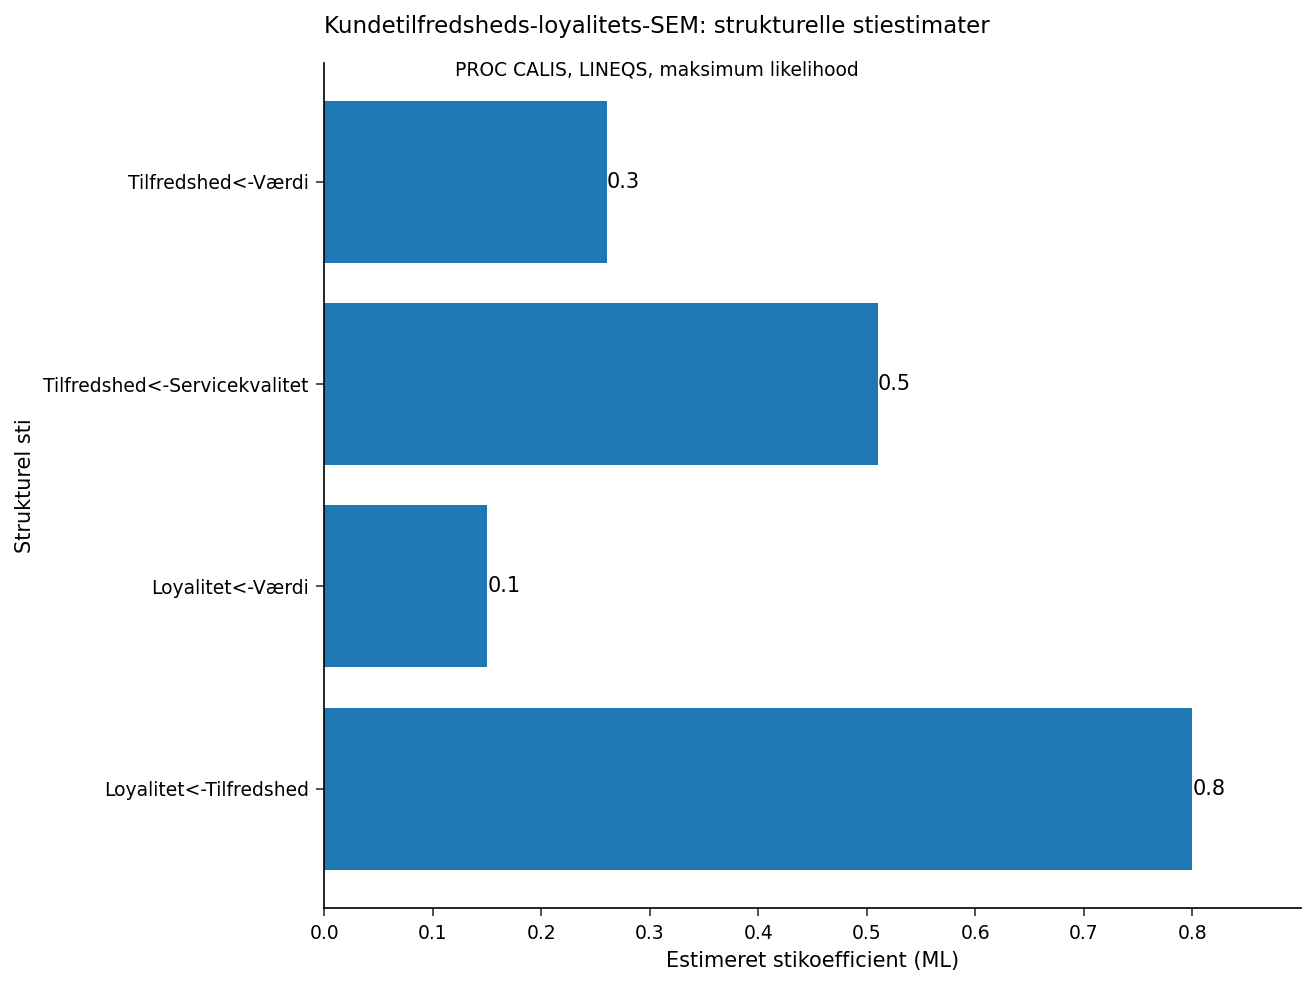

In [4]:
/* Structural path estimates from the PROC CALIS fit above */
data paths;
   LÆNGDE path $30;
   INDDATA path $ coef;
   DATALINES;
Loyalitet<-Tilfredshed 0.80
Tilfredshed<-Servicekvalitet 0.51
Tilfredshed<-Værdi 0.26
Loyalitet<-Værdi 0.15
;
KØR;

PROCEDURE SGPLOT data=paths;
   HBAR path / RESPONSE=coef DATALABEL
               fillattrs=(color=steelblue);
   XAXIS MÆRKAT="Estimeret stikoefficient (ML)" MIN=0 MAX=0.9;
   YAXIS MÆRKAT="Strukturel sti" discreteorder=data;
   TITEL  "Kundetilfredsheds-loyalitets-SEM: strukturelle stiestimater";
   title2 "PROC CALIS, LINEQS, maksimum likelihood";
KØR;

## Fortolkning af resultaterne

**Målemodel.** Hver frigjort loading er stor og højsignifikant (alle t > 13, p < 0.0001): `q2`/`q3` lader ~0.91 på ServQual, `v2`/`v3` lader ~0.99 og 0.84 på Value, `s2`/`s3` lader ~1.03 og 0.90 på Satis, og `l2`/`l3` lader ~0.88 og 0.82 på Loyal. Fejlvarianserne er beskedne i forhold til indikatorvarianserne, så hvert tre-items-batteri måler rent sit tilsigtede konstrukt — den validitetskontrol, der retfærdiggør at behandle items som proxyer for de latente konstrukter.

**Strukturmodel.** De estimerede stier besvarer forretningsspørgsmålet direkte:
- **Tilfredshed** drives mere af **servicekvalitet** (`b_sat_sq` = 0.51, t = 7.99) end af **opfattet værdi** (`b_sat_val` = 0.26, t = 3.86). Investering i servicekvalitet flytter tilfredsheden cirka dobbelt så meget pr. enhed.
- **Loyalitet** domineres af **tilfredshed** (`b_loy_sat` = 0.80, t = 8.54) med kun en lille *direkte* værdisti (`b_loy_val` = 0.15, t = 2.02), der omgår tilfredshed.
- De to drivere er positivt korreleret (ServQual–Value-kovarians 0.44, t = 3.36), som forventet, når begge afspejler en fælles underliggende oplevelse.

**Effektdekomponering.** Ved at multiplicere langs kæden adskilles den indirekte (gennem-tilfredshed) kanal fra den direkte:
- **Værdi → loyalitet:** indirekte = 0.26 × 0.80 = **0.21**, direkte = **0.15**, i alt ≈ **0.36**. Det meste af værdiens træk på loyalitet flyder gennem tilfredshed.
- **Servicekvalitet → loyalitet:** der er ingen direkte sti, så hele effekten er indirekte = 0.51 × 0.80 = **0.41** — den enkeltstående største driver af loyalitet i modellen.

Dette kvantificerer den strategiske påstand: *at forbedre tilfredsheden er den primære løftestang for loyalitet*, og servicekvalitet er den mest effektive måde at hæve tilfredsheden på i første omgang.

**Tilpasning.** Modellen reproducerer de observerede kovarianser godt — chi-i-anden = 50.81 (df = 49, p = 0.40, en ikke-signifikant værdi, der indikerer ingen påviselig fejltilpasning), RMSEA = 0.019 (et godt stykke under tærsklen på 0.05 for "tæt tilpasning"), CFI = 0.999 og TLI = 0.998 (begge over benchmarket på 0.95). Den hypotetiserede tilfredsheds-medierer-loyalitet-kæde er fuldt i overensstemmelse med data.

Kort sagt: detailhandleren kan aflæse, hvor meget loyalitet der *fremstilles gennem tilfredshed*, og hvilken driver — servicekvalitet eller værdi — der mest effektivt hæver tilfredsheden i første omgang.